# Optimizing the Piezo Position

``` Pseudo
1. Get scanners current position
2. Set resolution (we know range will be 1 um in the xy plane)
3. Build the sequence, centered around the current position
4. For each position in sequence, go to that position and take an image
5. Calculate the total brightness for each image, and fit a gaussian distribution to the sequence
6. Plot
```

### Scanner Architecture: GUI to Hardware

- **For positioning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_ao** → Hardware
- **For scanning**: ScannerGui → ScanningProbeLogic → NiScanningProbeInterfuse → **ni_finite_sampling_io** → Hardware
- Interfuse selects appropriate hardware
Piezo stages: x, y, z axes
    - ao0 → x-axis
    - ao1 → y-axis  
    - ao2 → z-axis

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import cv2

## SPAD Configuration

In [21]:
spad = camera_SPC3
spad._NFrames = 1 
spad._apply_camera_settings()

## Building the Sequence

### Optimization Params
- resolution_x = 3 # pixels
- resolution_y = 3 # pixels
- scan_range_x = 1e-6 # units are in m; 1 micron for both x and y ensures pixel is centered on nv
- scan_range_y = 1e-6

In [22]:
resolution_x = 10 # pixels
resolution_y = 10 # pixels
scan_range_x = 1.0e-6 # meters
scan_range_y = 1.0e-6 # meters
arr_dim = 5 # what are the number of nv's in each row and column of the array

piezo = scanning_probe_logic
x_l_bound, x_u_bound = piezo.scanner_constraints.axes['x'].position.bounds
y_l_bound, y_u_bound = piezo.scanner_constraints.axes['y'].position.bounds

# Build sequence
curr_pos = piezo.scanner_position # make sure it's centered; maybe add some logic later to do a quick edge detection
curr_pos = {k: float(v) for k, v in curr_pos.items()}
start_x = curr_pos['x'] - scan_range_x / 2
start_y = curr_pos['y'] - scan_range_y / 2
sequence_x = np.linspace(start_x, start_x + scan_range_x, int(resolution_x))
sequence_y = np.linspace(start_y, start_y + scan_range_y, int(resolution_y))
w, h = spad.get_size()

if sequence_x[0] < x_l_bound or sequence_x[-1] > x_u_bound:
    raise ValueError(f"X scan range [{sequence_x[0]:.2e}, {sequence_x[-1]:.2e}] m exceeds scanner bounds [{x_l_bound:.2e}, {x_u_bound:.2e}] m")

if sequence_y[0] < y_l_bound or sequence_y[-1] > y_u_bound:
    raise ValueError(f"Y scan range [{sequence_y[0]:.2e}, {sequence_y[-1]:.2e}] m exceeds scanner bounds [{y_l_bound:.2e}, {y_u_bound:.2e}] m")

print(curr_pos)

{'x': 0.0001712984, 'y': 2.60596e-05, 'z': 0.0001018735}


## Sampling Images

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [23]:
pos_dict = {k: float(v) for k, v in curr_pos.items()}
img_samples = np.zeros((resolution_x * resolution_y, h, w), dtype=np.float32)

idx = 0
for y_sample in sequence_y:
    for x_sample in sequence_x:
        pos_dict['x'] = float(x_sample)
        pos_dict['y'] = float(y_sample)
        
        position = piezo.set_target_position(pos_dict, move_blocking=True)
        
        frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
        img_samples[idx] = frame
        idx += 1
        print(f"Captured frame {idx}/{resolution_x * resolution_y}")

print(f"Final shape: {img_samples.shape}")

Captured frame 1/100
Captured frame 2/100
Captured frame 3/100
Captured frame 4/100
Captured frame 5/100
Captured frame 6/100
Captured frame 7/100
Captured frame 8/100
Captured frame 9/100
Captured frame 10/100
Captured frame 11/100
Captured frame 12/100
Captured frame 13/100
Captured frame 14/100
Captured frame 15/100
Captured frame 16/100
Captured frame 17/100
Captured frame 18/100
Captured frame 19/100
Captured frame 20/100
Captured frame 21/100
Captured frame 22/100
Captured frame 23/100
Captured frame 24/100
Captured frame 25/100
Captured frame 26/100
Captured frame 27/100
Captured frame 28/100
Captured frame 29/100
Captured frame 30/100
Captured frame 31/100
Captured frame 32/100
Captured frame 33/100
Captured frame 34/100
Captured frame 35/100
Captured frame 36/100
Captured frame 37/100
Captured frame 38/100
Captured frame 39/100
Captured frame 40/100
Captured frame 41/100
Captured frame 42/100
Captured frame 43/100
Captured frame 44/100
Captured frame 45/100
Captured frame 46/1

## Calculating the Brightness Using a Kernel

In [27]:
img_samples = np.nan_to_num(img_samples, 0)

array_size_microns = 2 * arr_dim - 1 

pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns

nv_size_x = int(pxl_per_micron_x)  # pixels per NV
nv_size_y = int(pxl_per_micron_y)

# Kernel stride
spacing_x = int(2 * pxl_per_micron_x)  
spacing_y = int(2 * pxl_per_micron_y)

# Kernel = 1 micron NV box
kernel = np.ones((nv_size_y, nv_size_x), dtype=np.float32)

nv_brightness = np.array([
    cv2.filter2D(img, -1, kernel)[:arr_dim*spacing_y:spacing_y, :arr_dim*spacing_x:spacing_x]
    for img in img_samples
])

print(f"Original: {img_samples.shape}")
print(f"Array FOV: {array_size_microns} microns")
print(f"Pixels per micron: {pxl_per_micron_x:.2f}")
print(f"NV size: {nv_size_y}x{nv_size_x} pixels")
print(f"Center-to-center: {spacing_y}x{spacing_x} pixels")
print(f"Result: {nv_brightness.shape}")

Original: (100, 32, 32)
Array FOV: 9 microns
Pixels per micron: 3.56
NV size: 3x3 pixels
Center-to-center: 7x7 pixels
Result: (100, 5, 5)


## Create Overlap Function and Fit Data - CHECK

In [ ]:
nv_brightness = np.sum(nv_brightness, axis=(1, 2)) # (resolution_y * resolution_x, 1)
nv_brightness = np.reshape(nv_brightness, (resolution_y, resolution_x)) # (resolution_y, resolution_x, 1)

In [ ]:
# CHECK

def square_overlap_area(dx, dy):
    ox = np.maximum(0.0, 1 - np.abs(dx))
    oy = np.maximum(0.0, 1 - np.abs(dy))
    return ox * oy

def overlap_function(XY, A, x0, y0, C):
    x, y = XY
    return (A * square_overlap_area(x - x0, y - y0) + C).ravel()

X, Y = np.meshgrid(sequence_x, sequence_y, indexing="xy")

j, i = np.unravel_index(np.argmax(nv_brightness), nv_brightness.shape)
x0_guess = X[j, i]
y0_guess = Y[j, i]
C_guess = float(np.min(nv_brightness))
A_guess = float(nv_brightness[j, i] - C_guess)

p0 = (A_guess, x0_guess, y0_guess, C_guess)

bounds = (
    [0.0, sequence_x[0], sequence_y[0], -np.inf],
    [np.inf, sequence_x[-1], sequence_y[-1],  np.inf]
) # A, x0, y0, C; constrains possible values for optimal position

popt, _ = curve_fit(
    overlap_function,
    (X, Y),
    nv_brightness.ravel(),
    p0=p0,
    bounds=bounds
)

A_fit, x0_fit, y0_fit, C_fit = popt

pos_dict['x'], pos_dict['y'] = float(x0_fit), float(y0_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
frame = np.flipud(frame)
plt.title(f"Optimal position in XY: ({x0_fit*10**6:.3f}, {y0_fit*10**6:.3f} microns)")
plt.imshow(frame)

print("Peak location:", x0_fit, y0_fit)
print("A, C:", A_fit, C_fit)


## Plot Fit - CHECK

In [ ]:
pred = A_fit * square_overlap_area(X - x0_fit, Y - y0_fit) + C_fit
resid = nv_brightness - pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Measured")
plt.imshow(nv_brightness, origin="lower")
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 2)
plt.title("Predicted (fit)")
plt.imshow(pred, origin="lower")
plt.colorbar(fraction=0.046)

plt.subplot(1, 3, 3)
plt.title("Residual (meas - pred)")
plt.imshow(resid, origin="lower")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()


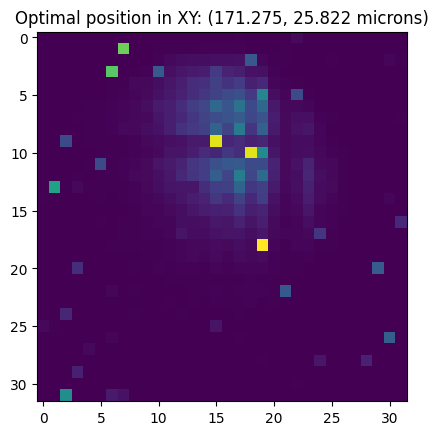

In [ ]:
# SAVE FOR Z-FIT
def gaussian_2d(xy, amplitude, xo, yo, sigma_x, sigma_y, offset):
    x, y = xy
    g = offset + amplitude * np.exp(
        -(((x - xo) ** 2) / (2 * sigma_x ** 2) + ((y - yo) ** 2) / (2 * sigma_y ** 2))
    )

    # add distance from center penalty
    return g.ravel()



initial_guess = (
    np.max(nv_brightness),  # amplitude
    curr_pos['x'],  # xo (center x)
    curr_pos['y'],  # yo (center y)
    scan_range_x / 4,  # sigma_x
    scan_range_y / 4,  # sigma_y
    np.min(nv_brightness)  # offset
)

position_opt, _ = curve_fit(
    gaussian_2d, 
    (X.ravel(), Y.ravel()), 
    nv_brightness.ravel(), 
    p0=initial_guess
)

amplitude, xo, yo, sigma_x, sigma_y, offset = position_opt

fit = gaussian_2d((X, Y), *position_opt).reshape(resolution_x, resolution_y)

pos_dict['x'], pos_dict['y'] = float(xo), float(yo)
position = piezo.set_target_position(pos_dict, move_blocking=True)
frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
frame = np.flipud(frame)
plt.title(f"Optimal position in XY: ({xo*10**6:.3f}, {yo*10**6:.3f} microns)")
plt.imshow(frame)